In [13]:
!pip install biopython requests pandas matplotlib py3Dmol -q
!apt-get update -y
!apt-get install openbabel -y -qq

!wget https://github.com/gnina/gnina/releases/download/v1.1/gnina -O gnina
!chmod +x gnina
!./gnina --help

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,238 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
--2026-06-01 18:40:06--  https://github.com/gnina/gnina/releases/download/v1.1/gnina
Resolving github.com (github.com)... 140.82.114.3
Connecting t

In [14]:
from Bio import Entrez, SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.PDB import PDBParser, PDBIO, Select, Superimposer
from IPython.display import display, HTML

import pandas as pd
import numpy as np
import requests
import py3Dmol
import matplotlib.pyplot as plt
import os

In [16]:
Entrez.email = "subhanajamil3@gmail.com"

gene = "MYC"
ncbi_mrna_id = "NM_002467.6"
protein_ref_id = "NP_002458.2"

print("Gene selected:", gene)
print("mRNA ID:", ncbi_mrna_id)
print("Protein Ref:", protein_ref_id)

Gene selected: MYC
mRNA ID: NM_002467.6
Protein Ref: NP_002458.2


In [53]:
handle = Entrez.efetch(
    db="nucleotide",
    id="NM_002467.6",
    rettype="gb",
    retmode="text"
)

record = SeqIO.read(handle, "genbank")
handle.close()

print("Sequence ID:", record.id)
print("Sequence Length:", len(record.seq))

Sequence ID: NM_002467.6
Sequence Length: 3721


In [54]:
cds_seq = None

for feature in record.features:
    if feature.type == "CDS":
        cds_seq = feature.extract(record.seq)
        break

if cds_seq is None:
    raise ValueError("Coding region not found")

print("CDS length:", len(cds_seq))

CDS length: 1365


In [55]:
mrna = cds_seq.transcribe()

print("mRNA length:", len(mrna))
print(mrna[:100])

mRNA length: 1365
CUGGAUUUUUUUCGGGUAGUGGAAAACCAGCAGCCUCCCGCGACGAUGCCCCUCAACGUUAGCUUCACCAACAGGAACUAUGACCUCGACUACGACUCGG


In [56]:
blast_result = NCBIWWW.qblast(
    "blastn",
    "nt",
    str(mrna),
    hitlist_size=5
)

with open("MYC_blast.xml", "w") as f:
    f.write(blast_result.read())

In [57]:
protein = mrna.translate(to_stop=True)

print("Protein length:", len(protein))
print(protein[:100])

Protein length: 454
LDFFRVVENQQPPATMPLNVSFTNRNYDLDYDSVQPYFYCDEEENFYQQQQQSELQPPAPSEDIWKKFELLPTPPLSPSRRSGLCSPSYVAVTPFSLRGD


In [58]:
handle = Entrez.efetch(
    db="protein",
    id="NP_002458.2",
    rettype="fasta",
    retmode="text"
)

ref_protein = SeqIO.read(handle, "fasta").seq
handle.close()

print("Reference protein loaded")

Reference protein loaded


In [67]:
url = "https://alphafold.ebi.ac.uk/files/AF-P01106-F1-model_v6.pdb"
r = requests.get(url)

with open("MYC_alphafold.pdb", "w") as f:
    f.write(r.text)

In [69]:
view = py3Dmol.view(width=800, height=400)

with open("MYC_alphafold.pdb") as f:
    view.addModel(f.read(), "pdb")

view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [74]:
import requests

cid = "9835049"
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/SDF"

r = requests.get(url)

print("Status:", r.status_code)
print(r.text[:200])

if "V2000" in r.text or "M  END" in r.text:
    with open("MYC_ligand.sdf", "w") as f:
        f.write(r.text)
    print("Ligand saved correctly")
else:
    raise ValueError("Invalid ligand file downloaded")

Status: 200
9835049
  -OEChem-06012615462D

 28 29  0     1  0  0  0  0  0999 V2000
    8.6610   -1.3724    0.0000 S   0  0  0  0  0  0  0  0  0  0  0  0
    7.6610   -1.3724    0.0000 O   0  0  0  0  0  0  0  0 
Ligand saved correctly


In [77]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("MYC", "MYC_alphafold.pdb")

coords = [atom.coord for atom in structure.get_atoms()]
coords = np.array(coords)

print("Atoms:", len(coords))

if len(coords) == 0:
    raise ValueError("Empty protein structure")

center = coords.mean(axis=0)

print("Docking center:", center)

Atoms: 3551
Docking center: [  8.156444     0.55769205 -15.769715  ]


In [84]:
gnina_command = f"""./gnina \
-r MYC_alphafold.pdb \
-l MYC_ligand.pdbqt \
--center_x {center[0]:.3f} \
--center_y {center[1]:.3f} \
--center_z {center[2]:.3f} \
--size_x 40 \
--size_y 40 \
--size_z 40 \
--num_modes 10 \
-o MYC_docked.sdf
"""

!{gnina_command}

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.1 master:e4cb380+   Built Dec 18 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Recommend running with single model (--cnn crossdock_default2018)
or without cnn scoring (--cnn_scoring=none).

Commandline: ./gnina -r MYC_alphafold.pdb -l MYC_ligand.pdbqt --center_x 8.156 --center_y 0.558 --center_z -15.770 --size_x 40 --size_y 40 --size_z 40 --num_modes 10 -o MYC_docked.sdf
*** Open Babel Warning  in Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

Using random seed: 834338385

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|--

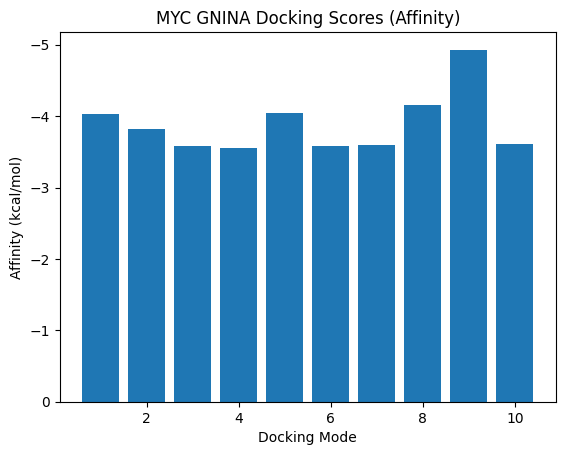

In [85]:
import matplotlib.pyplot as plt

modes = list(range(1, 11))

scores = [
    -4.03, -3.82, -3.58, -3.56, -4.05,
    -3.58, -3.60, -4.16, -4.93, -3.61
]

plt.bar(modes, scores)
plt.gca().invert_yaxis()
plt.title("MYC GNINA Docking Scores (Affinity)")
plt.xlabel("Docking Mode")
plt.ylabel("Affinity (kcal/mol)")
plt.show()

In [86]:
import py3Dmol

view = py3Dmol.view(width=800, height=400)

# Protein
view.addModel(open("MYC_alphafold.pdb").read(), "pdb")
view.setStyle({"cartoon": {"color": "blue"}})

# Docked ligand (GNINA output SDF)
view.addModel(open("MYC_docked.sdf").read(), "sdf")
view.setStyle({"stick": {"colorscheme": "greenCarbon"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [87]:
from IPython.display import HTML
import py3Dmol

# Title
display(HTML("<h3>MYC–10058-F4 Docked Complex</h3>"))

# Protein
with open("MYC_alphafold.pdb") as f:
    protein = f.read()

# Docked ligand from GNINA output (SDF)
with open("MYC_docked.sdf") as f:
    ligand = f.read()

# Viewer
view = py3Dmol.view(width=850, height=500)

# Protein structure
view.addModel(protein, "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})

# Docked ligand
view.addModel(ligand, "sdf")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "greenCarbon"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.